# AP 155 Lab Exercise
---
## Exercise 4: Derivatives

_Instructions_: 
- **Report figure (See Problem 1):** Plot of mean absolute error vs. step size (spacing between points) when using the forward, backward, and central difference approach to get first derivative
- **Report discussion:** Explain the results of your figure. How do the central and non-central difference formulas arrive at such accuracies? Looking outward, when is each method of differentiation suitable/appropriate? 
  
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: de Vera, Clarence Joseph
- _Student No._: 2024-11757
- _Section_: THR-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.

### Report discussion

As the step size decreases, the error also decreases for all three methods of differentiation. The central difference line drops much faster (slope of 2) on the log-log plot—compared to the forward and backward lines (slope of 1). This means the central difference reaches much better accuracy at larger step sizes. However, once h reaches reaches very low values, the error stops decreasing and starts fluctuating or rising. This happens because the computer reaches its floating-point precision limit, causing subtraction errors when dealing with nearly identical numbers.

The central difference method is best for points in the middle of a dataset because having data on both sides gives much better accuracy without extra work. However, non-central formulas are needed at the edges where neighboring points do not exist. Forward difference is used at the starting edge or when predicting future data, while backward difference is used at the ending edge or when analyzing historical data.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1:

Consider the function:
$$ f(x) = 2 + 5x\sin\left(x + \frac{\pi}{4}\right)$$

Say you start with 257 points from 0 to $4\pi$ 

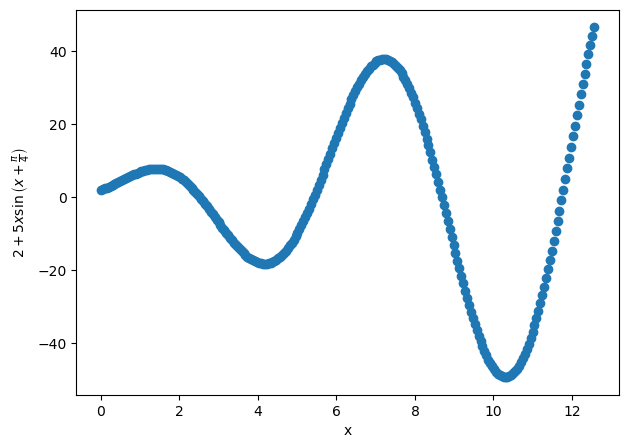

In [2]:
f_0 = lambda x: 2 + 5*x*np.sin(1*x+np.pi/4)
x = np.linspace(0, 4*np.pi, 257)
fig, ax = plt.subplots(figsize = (7,5))
ax.scatter(x, f_0(x))
ax.set_ylabel(r"$2 + 5x\sin\left(x + \frac{\pi}{4}\right)$")
ax.set_xlabel("x")
fig.show()
fig.savefig('f_x.png')

- Create a function that gets the first derivative approximation using the forward, backward, and central difference formulas. (Bonus, not required): Make the function flexible to non-evenly spaced data
- To give yourself a visualization, plot (in a single axis):
  - the three derivative approximations
  - the analytically derived function

- Get the mean absolute error of each of the approximations compared to the analytically derived function
- Repeat the above step for increasing number of points (decreasing spacing) - instead of 256 points, take 512/1024/128/64 points, etc.

- (For the report) Make a plot of the mean absolute error vs the spacing between points. In this plot, there should be three curves: One for the forward, one for the backward, and one for the central difference approximation

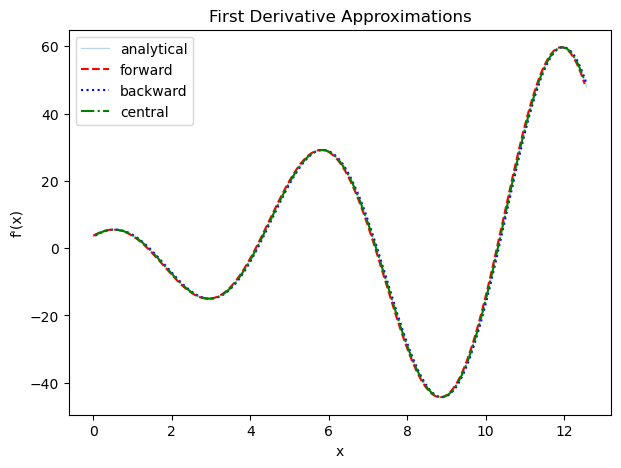

In [3]:
import numpy as np
import matplotlib.pyplot as plt

f_0 = lambda x: 2 + 5 * x * np.sin(x + np.pi/4)
f_prime = lambda x: 5 * np.sin(x + np.pi/4) + 5 * x * np.cos(x + np.pi/4)

def get_derivs(x, y):
    dx_fwd = x[1:] - x[:-1]
    dy_fwd = y[1:] - y[:-1]
    
    # forward difference
    fwd = dy_fwd / dx_fwd
    x_fwd = x[:-1]
    
    # backward difference
    bwd = dy_fwd / dx_fwd
    x_bwd = x[1:]
    
    # central difference
    dx_cen = x[2:] - x[:-2]
    dy_cen = y[2:] - y[:-2]
    cen = dy_cen / dx_cen
    x_cen = x[1:-1]
    
    return x_fwd, fwd, x_bwd, bwd, x_cen, cen


x = np.linspace(0, 4*np.pi, 256)
y = f_0(x)

xf, fwd, xb, bwd, xc, cen = get_derivs(x, y)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x, f_prime(x), label='analytical', lw=1, alpha=0.3)
ax.plot(xf, fwd, color="red", linestyle="--", label='forward')
ax.plot(xb, bwd, color="blue", linestyle=":", label='backward')
ax.plot(xc, cen, color="green", linestyle="-.", label='central')
ax.set_title("First Derivative Approximations")
ax.set_xlabel('x')
ax.set_ylabel("f'(x)")
ax.legend()
fig.savefig('fda.png')
plt.show()

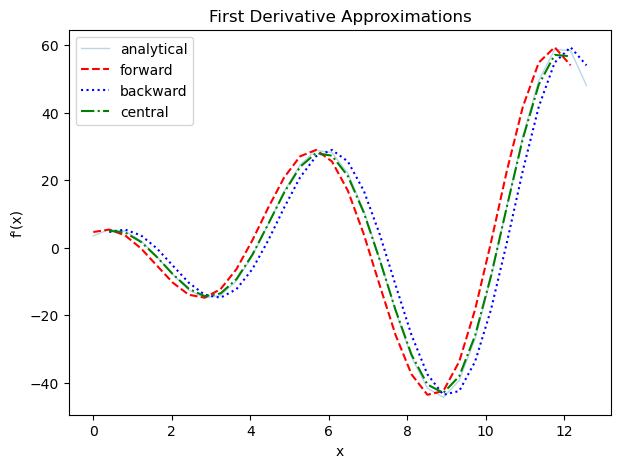

In [4]:
x = np.linspace(0, 4*np.pi, 32)
y = f_0(x)

xf, fwd, xb, bwd, xc, cen = get_derivs(x, y)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x, f_prime(x), label='analytical', lw=1, alpha=0.3)
ax.plot(xf, fwd, color="red", linestyle="--", label='forward')
ax.plot(xb, bwd, color="blue", linestyle=":", label='backward')
ax.plot(xc, cen, color="green", linestyle="-.", label='central')
ax.set_title("First Derivative Approximations")
ax.set_xlabel('x')
ax.set_ylabel("f'(x)")
ax.legend()
fig.savefig('fda.png')
plt.show()

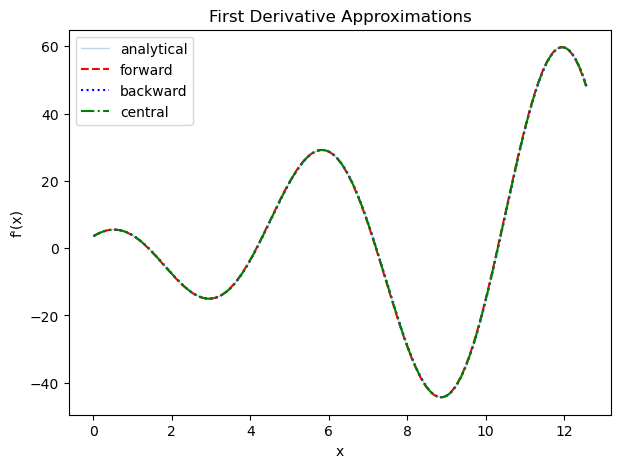

In [5]:
x = np.linspace(0, 4*np.pi, 1024)
y = f_0(x)

xf, fwd, xb, bwd, xc, cen = get_derivs(x, y)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x, f_prime(x), label='analytical', lw=1, alpha=0.3)
ax.plot(xf, fwd, color="red", linestyle="--", label='forward')
ax.plot(xb, bwd, color="blue", linestyle=":", label='backward')
ax.plot(xc, cen, color="green", linestyle="-.", label='central')
ax.set_title("First Derivative Approximations")
ax.set_xlabel('x')
ax.set_ylabel("f'(x)")
ax.legend()
fig.savefig('fda.png')
plt.show()

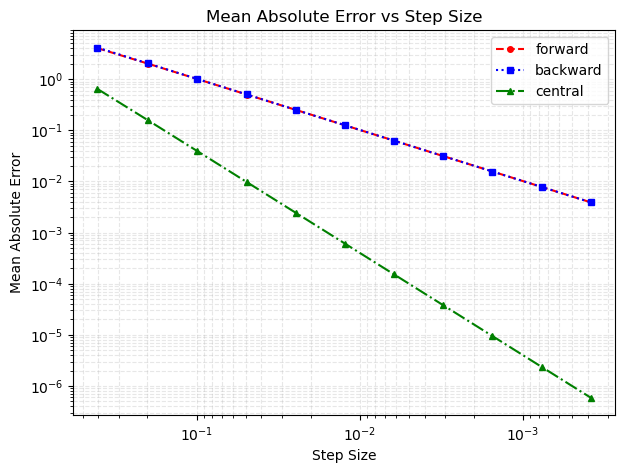

In [9]:
import numpy as np
import matplotlib.pyplot as plt
N_list = [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]

stepsize = []
mae_fwd = []
mae_bwd = []
mae_cen = []

for N in N_list:
    x_n = np.linspace(0, 4*np.pi, N)
    y_n = f_0(x_n)
    
    # stepsize
    h = x_n[1] - x_n[0]
    stepsize.append(h)
    
    # derivatives
    xf, fwd, xb, bwd, xc, cen = get_derivs(x_n, y_n)
    
    # MAE
    mae_fwd.append(np.mean(np.abs(fwd - f_prime(xf))))
    mae_bwd.append(np.mean(np.abs(bwd - f_prime(xb))))
    mae_cen.append(np.mean(np.abs(cen - f_prime(xc))))

fig2, ax2 = plt.subplots(figsize=(7, 5))

ax2.plot(stepsize, mae_fwd, color="red", linestyle="--", marker="o", markersize=4, label='forward')
ax2.plot(stepsize, mae_bwd, color="blue", linestyle=":", marker="s", markersize=4, label='backward')
ax2.plot(stepsize, mae_cen, color="green", linestyle="-.", marker="^", markersize=4, label='central')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.invert_xaxis()  #left to right

ax2.set_title("Mean Absolute Error vs Step Size")
ax2.set_xlabel('Step Size')
ax2.set_ylabel('Mean Absolute Error')
ax2.legend()
ax2.grid(True, which="both", ls="--", alpha=0.3)

fig2.savefig('maevsss.png')
plt.show()

#### Problem 1 code summary

This script compares forward, backward, and central difference formulas against the a given mathematical derivative across smaller and smaller step sizes. Array slicing was used instead of slow loops to make the code fast and automatically handle unevenly spaced points. Running a grid from N = 2^5 to N = 2^15 shows how accuracy improves as step size decreases, but breaks down when the step size reaches very small values due to the computer reaching its floating-point precision limit (I was unable to show this due to the kernel just dying whenever I put more values, up to the required value for this to happen).

---

## Section 3 (Notes)

### Non-central difference formulas (First Derivative)

* Forward 
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{x})}{h} + O(h)
$$

* Backward
$$
f'(x_i) = \frac{f(x_{i}) - f(x_{i-1})}{h} + O(h)
$$



### Central-difference formulas

* First Derivative
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{i-1})}{2h} + O(h^2)
$$

* Second Derivative
$$
f''(x_i) = \frac{f(x_{i+1}) - 2f(x_{i}) + f(x_{i-1})}{h^2} + O(h^2)
$$

Note: to avoid confusion, think: $x_i$ is `x[i]`, and $h$ is the gap between `x[i+1]` and `x[i]`.


In [7]:
## Useful tips. Not required to solve the problems below!

# Suppose you have a Numpy array
x = np.linspace(1, 10, 10)
print(x)

# I can move all values to the left/right using roll
x_roll = np.roll(x, 1) # change 1 to -1, what happens? 
x_roll2 = np.roll(x, -1)
print(x_roll)

# then I could exploit array operations to get their difference
x_diff = (x_roll - x)[1:]
print(x_diff)
# Be careful with the boundaries!

x_diff2 = (x_roll2 - x_roll)[:]
print(x_diff2)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[10.  1.  2.  3.  4.  5.  6.  7.  8.  9.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-8.  2.  2.  2.  2.  2.  2.  2.  2. -8.]
